## Classical ML Model #2: **Random Forest Classifier**

First, we will import our pre-split and scaled training, validation, and test sets.

In [1]:
import pandas as pd
import joblib

# Load the preprocessed and scaled data
X_train_scaled = joblib.load('processed_data/X_train_scaled.pkl')
X_val_scaled = joblib.load('processed_data/X_val_scaled.pkl')
X_test_scaled = joblib.load('processed_data/X_test_scaled.pkl')

y_train = joblib.load('processed_data/y_train.pkl')
y_val = joblib.load('processed_data/y_val.pkl')
y_test = joblib.load('processed_data/y_test.pkl')

# **[4]** Model Selection Training


For the second model, we are implementing a **Random Forest Classifier**. This is a powerful ensemble learning method that builds multiple decision trees and merges them together to get a more accurate and stable prediction. It is naturally robust to non-linear relationships and will help us easily interpret which socioeconomic features are most important for predicting urbanization.</br></br>

To initialize our model, we set `andom_state` to 42 so we can ensure our results are reproducible for every run. `n_jobs` parameter determines the number of CPU cores to use for running parallel processes. We set it to `-1` to use all available CPU cores, maximizing the potential speed benefit.

In [2]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model on the scaled training data
rf_model.fit(X_train_scaled, y_train)

print("Random Forest model successfully trained!")

Random Forest model successfully trained!


# **[5]** Error Analysis and Model Tuning

Before finalizing our Random Forest, we need to analyze where our baseline model makes mistakes. We will generate predictions on our **Validation Set** and evaluate it using our 7 chosen metrics: Accuracy, Precision, Recall, F1-Score, Confusion Matrix, AUC-ROC, and AUC-PR.

Baseline Random Forest Metrics (Validation Set)
1) Accuracy:  0.8100
2) Precision: 0.8016
3) Recall:    0.6691
4) F1 Score:  0.7294
6) AUC-ROC:   0.8786
7) AUC-PR:    0.8448



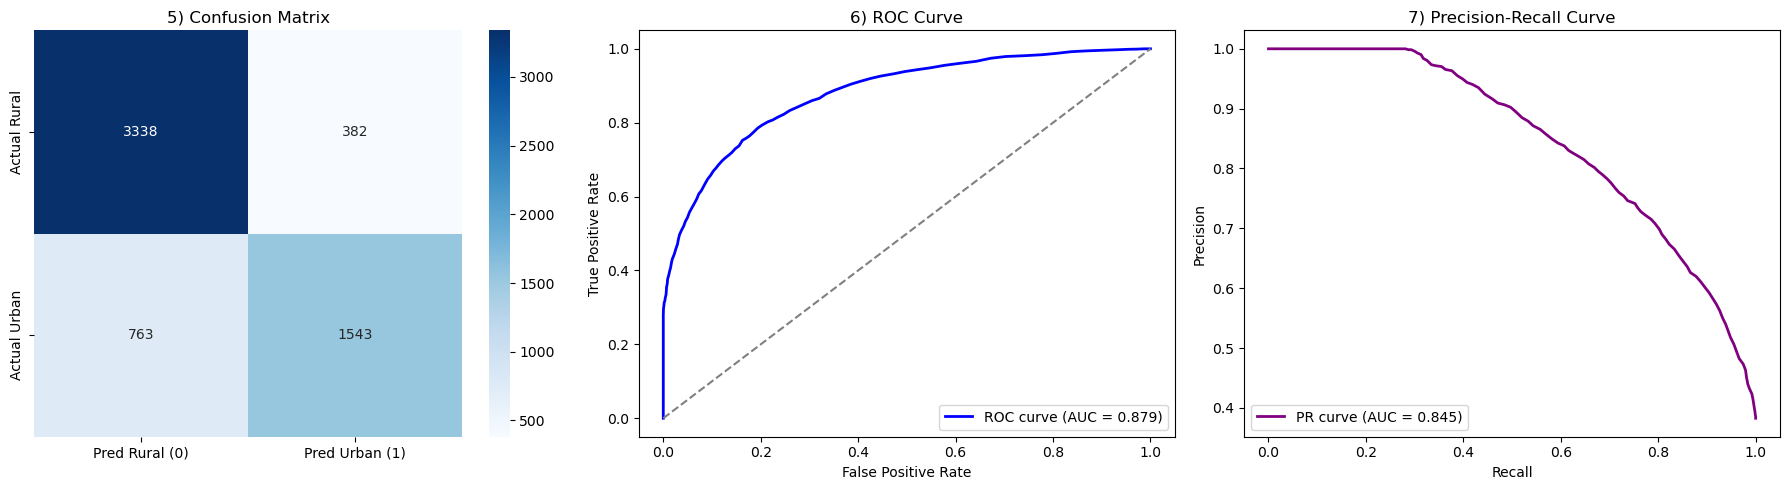

In [3]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, roc_auc_score, average_precision_score, 
    roc_curve, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# Get standard predictions (0 or 1) and probability predictions
rf_y_val_pred = rf_model.predict(X_val_scaled)
rf_y_val_prob = rf_model.predict_proba(X_val_scaled)[:, 1] # Probability of Class 1 (Urban)

# Calculate single-number metrics
rf_acc = accuracy_score(y_val, rf_y_val_pred)
rf_prec = precision_score(y_val, rf_y_val_pred)
rf_rec = recall_score(y_val, rf_y_val_pred)
rf_f1 = f1_score(y_val, rf_y_val_pred)
rf_roc_auc = roc_auc_score(y_val, rf_y_val_prob)
rf_pr_auc = average_precision_score(y_val, rf_y_val_prob)

print("Baseline Random Forest Metrics (Validation Set)")
print(f"1) Accuracy:  {rf_acc:.4f}")
print(f"2) Precision: {rf_prec:.4f}")
print(f"3) Recall:    {rf_rec:.4f}")
print(f"4) F1 Score:  {rf_f1:.4f}")
print(f"6) AUC-ROC:   {rf_roc_auc:.4f}")
print(f"7) AUC-PR:    {rf_pr_auc:.4f}\n")

# Plotting the Visual Metrics (Confusion Matrix, ROC, PR)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Confusion Matrix
cm = confusion_matrix(y_val, rf_y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Rural (0)', 'Pred Urban (1)'], 
            yticklabels=['Actual Rural', 'Actual Urban'])
axes[0].set_title('5) Confusion Matrix')

# Plot B: ROC Curve
fpr, tpr, _ = roc_curve(y_val, rf_y_val_prob)
axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {rf_roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('6) ROC Curve')
axes[1].legend(loc="lower right")

# Plot C: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, rf_y_val_prob)
axes[2].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {rf_pr_auc:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('7) Precision-Recall Curve')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

### Hyperparameter Tuning (Grid Search)
Based on the error analysis above, we will now perform tune our model to optimize our F1-Score. We are using `GridSearchCV` to systematically test a grid of different hyperparameter combinations (number of trees, maximum depth, and minimum samples per split) using 3-fold Cross-Validation.

**Why optimize for the F1-Score?**
We are specifically telling our Grid Search to optimize for the **F1-Score** rather than standard Accuracy for three critical reasons:
1. **Imbalanced Data:** Our dataset is imbalanced. If there are more urban households than rural ones, a model could achieve high Accuracy simply by guessing "Urban" every time. The F1-Score prevents this by severely penalizing the model if it ignores the minority class.
2. **Balancing the Trade-off:** Optimizing solely for Precision would make the model too cautious (resulting in high false negatives), while optimizing for Recall would make it "trigger-happy" (resulting in high false positives). 
3. **The Harmonic Mean:** Because the F1-Score is the harmonic mean of Precision and Recall, it forces the Grid Search to find the specific hyperparameter combination that confidently identifies urban homes *without* sacrificing its ability to accurately classify rural homes.

In [4]:
from sklearn.model_selection import GridSearchCV

# Defining the grid of hyperparameters to test
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',       # Optimizing for F1-Score
    cv=3,               
    n_jobs=-1,
    verbose=2           
)

# Fit the Grid Search to the training data
grid_search.fit(X_train_scaled, y_train)

# Extract the best model
best_rf_model = grid_search.best_estimator_

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Hyperparameters: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 500}
Best Cross-Validation F1-Score: 0.7363


Unlike Neural Networks, a Random Forest does not use gradient descent or calculate a "loss function" (like Binary Cross-Entropy) over multiple training epochs. Instead, it builds independent decision trees simultaneously. 

To visualize how our model learns and improves, we can plot the Validation F1-Score against the number of trees in the forest (`n_estimators`). Generally, adding more trees improves the model's performance by reducing variance, but only up to a certain point where the performance will eventually plateau.

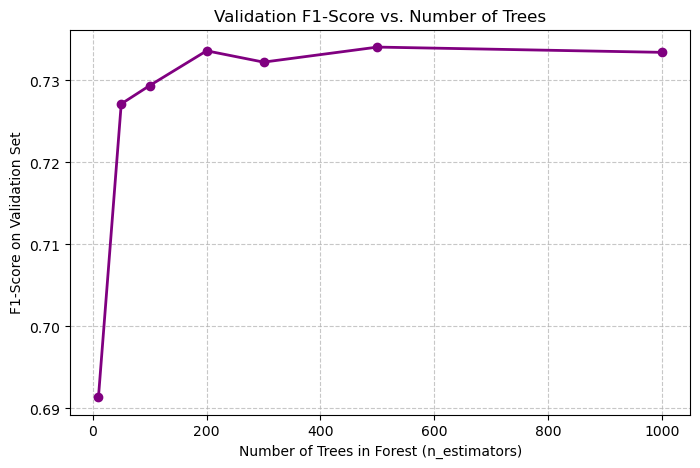

In [5]:
# Plotting Validation F1-Score vs Number of Trees
n_estimators_range = [10, 50, 100, 200, 300, 500, 1000]
val_f1_scores = []

# Loop through different numbers of trees and record the F1-Score
for n in n_estimators_range:
    temp_rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    temp_rf.fit(X_train_scaled, y_train)
    temp_preds = temp_rf.predict(X_val_scaled)
    val_f1_scores.append(f1_score(y_val, temp_preds))

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_range, val_f1_scores, marker='o', linestyle='-', color='purple', linewidth=2)
plt.title('Validation F1-Score vs. Number of Trees')
plt.xlabel('Number of Trees in Forest (n_estimators)')
plt.ylabel('F1-Score on Validation Set')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# **[6]** Model Evaluation

With our model fully tuned, we will now perform our final evaluation using the isolated test set. This provides an unbiased look at how our optimized Random Forest will perform on completely unseen household data.

Final Tuned Random Forest Metrics (Test Set)
1) Accuracy:  0.8194
2) Precision: 0.8188
3) Recall:    0.6782
4) F1 Score:  0.7419
6) AUC-ROC:   0.8880
7) AUC-PR:    0.8598



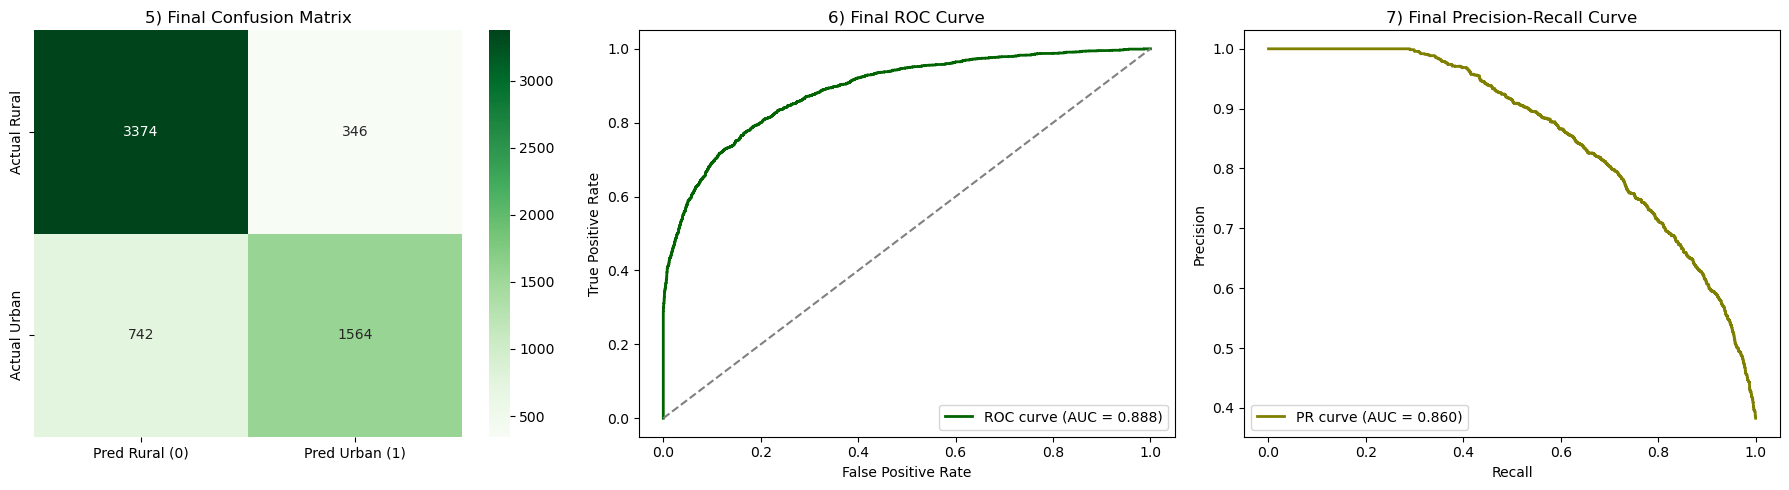

In [6]:
# Use the best model from Grid Search to predict the test set
rf_y_test_pred = best_rf_model.predict(X_test_scaled)
rf_y_test_prob = best_rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate final metrics
rf_test_acc = accuracy_score(y_test, rf_y_test_pred)
rf_test_prec = precision_score(y_test, rf_y_test_pred)
rf_test_rec = recall_score(y_test, rf_y_test_pred)
rf_test_f1 = f1_score(y_test, rf_y_test_pred)
rf_test_roc_auc = roc_auc_score(y_test, rf_y_test_prob)
rf_test_pr_auc = average_precision_score(y_test, rf_y_test_prob)

print("Final Tuned Random Forest Metrics (Test Set)")
print(f"1) Accuracy:  {rf_test_acc:.4f}")
print(f"2) Precision: {rf_test_prec:.4f}")
print(f"3) Recall:    {rf_test_rec:.4f}")
print(f"4) F1 Score:  {rf_test_f1:.4f}")
print(f"6) AUC-ROC:   {rf_test_roc_auc:.4f}")
print(f"7) AUC-PR:    {rf_test_pr_auc:.4f}\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Final Confusion Matrix
cm_test = confusion_matrix(y_test, rf_y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[0], 
            xticklabels=['Pred Rural (0)', 'Pred Urban (1)'], 
            yticklabels=['Actual Rural', 'Actual Urban'])
axes[0].set_title('5) Final Confusion Matrix')

# Plot B: Final ROC Curve
fpr_test, tpr_test, _ = roc_curve(y_test, rf_y_test_prob)
axes[1].plot(fpr_test, tpr_test, color='darkgreen', lw=2, label=f'ROC curve (AUC = {rf_test_roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('6) Final ROC Curve')
axes[1].legend(loc="lower right")

# Plot C: Final Precision-Recall Curve
precision_test, recall_test, _ = precision_recall_curve(y_test, rf_y_test_prob)
axes[2].plot(recall_test, precision_test, color='olive', lw=2, label=f'PR curve (AUC = {rf_test_pr_auc:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('7) Final Precision-Recall Curve')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

## Feature Importance Analysis
One of the primary advantages of the Random Forest algorithm is its interpretability. Below, we extract the feature importances from our best model to understand which household characteristics were the strongest predictors of urbanization.

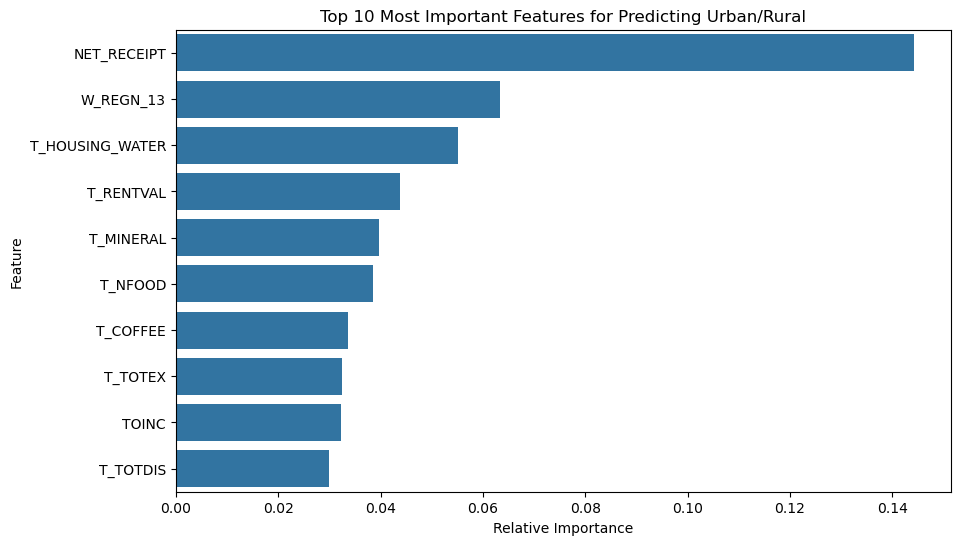

In [7]:
# Extract feature importances from the tuned model
importances = best_rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plotting the Top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature')
plt.title('Top 10 Most Important Features for Predicting Urban/Rural')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.show()

<hr/>

# AI Declaration
Chavez, Allen Visagar
- sample text

Llanes, Andre Gabriel De Ocampo
- sample text

Rojo, Von Matthew De Guzman *(leader)*
- Uses Google-search that has AI features in synthesizing different sources relevant to questions I asked.
- Uses Google Gemini to ask ways on how to import CSV dataset and scaffolding ideas for EDA

Tan, Jeremy James Teves
- sample text